In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
!wget -q --show-progress \
"https://archive.ics.uci.edu/static/public/908/realwaste.zip" \
-O /content/realwaste.zip

!unzip -q /content/realwaste.zip -d /content/realwaste

print("Dataset downloaded and extracted.")

/content/realwaste.     [  <=>               ] 656.65M  29.9MB/s    in 16s     
Dataset downloaded and extracted.


In [3]:
DATASET_PATH = "/content/realwaste/realwaste-main/RealWaste"

print(os.path.exists(DATASET_PATH))

True


In [4]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv
Saving validation.csv to validation.csv


In [5]:
train_df = pd.read_csv("/content/train.csv")
val_df = pd.read_csv("/content/validation.csv")
test_df = pd.read_csv("/content/test.csv")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3326
Validation: 713
Test: 713


In [6]:
class_names = sorted(train_df["label"].unique())

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Number of classes: 9


In [7]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

class_to_index

{'Cardboard': 0,
 'Food Organics': 1,
 'Glass': 2,
 'Metal': 3,
 'Miscellaneous Trash': 4,
 'Paper': 5,
 'Plastic': 6,
 'Textile Trash': 7,
 'Vegetation': 8}

In [8]:
def prepare_dataframe(dataframe):

    dataframe = dataframe.copy()

    dataframe["filepath"] = dataframe["relative_path"].apply(
        lambda x: os.path.join(DATASET_PATH, x)
    )

    dataframe["label_index"] = dataframe["label"].map(class_to_index)

    return dataframe


train_df = prepare_dataframe(train_df)
val_df = prepare_dataframe(val_df)
test_df = prepare_dataframe(test_df)

train_df.head()

,relative_path,label,filepath,label_index
0,Paper/Paper_191.jpg,Paper,/content/realwaste/realwaste-main/RealWaste/Pa...,5
1,Plastic/Plastic_329.jpg,Plastic,/content/realwaste/realwaste-main/RealWaste/Pl...,6
2,Food Organics/Food Organics_287.jpg,Food Organics,/content/realwaste/realwaste-main/RealWaste/Fo...,1
3,Metal/Metal_179.jpg,Metal,/content/realwaste/realwaste-main/RealWaste/Me...,3
4,Cardboard/Cardboard_285.jpg,Cardboard,/content/realwaste/realwaste-main/RealWaste/Ca...,0


In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", NUM_CLASSES)

Image size: 224
Batch size: 32
Classes: 9


In [10]:
def load_image(filepath, label):

    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [11]:
def create_dataset(dataframe, training=False):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label_index"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [12]:
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df
)

test_ds = create_dataset(
    test_df
)

print("Datasets ready.")

Datasets ready.


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

In [14]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [19]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.4753 - loss: 1.4421 - val_accuracy: 0.6508 - val_loss: 0.9555 - learning_rate: 0.0010
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.6933 - loss: 0.8691 - val_accuracy: 0.7377 - val_loss: 0.7782 - learning_rate: 0.0010
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.7327 - loss: 0.7408 - val_accuracy: 0.7307 - val_loss: 0.7386 - learning_rate: 0.0010
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.7670 - loss: 0.6493 - val_accuracy: 0.7489 - val_loss: 0.6876 - learning_rate: 0.0010
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.7847 - loss: 0.6111 - val_accuracy: 0.7672 - val_loss: 0.6616 - learning_rate: 0.0010
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.8004 - loss: 0.5774 - val_accuracy: 0.7784 - val_loss: 0.6416 - learning_rate: 0.0010
Epoch 7/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.8157 - loss: 0.

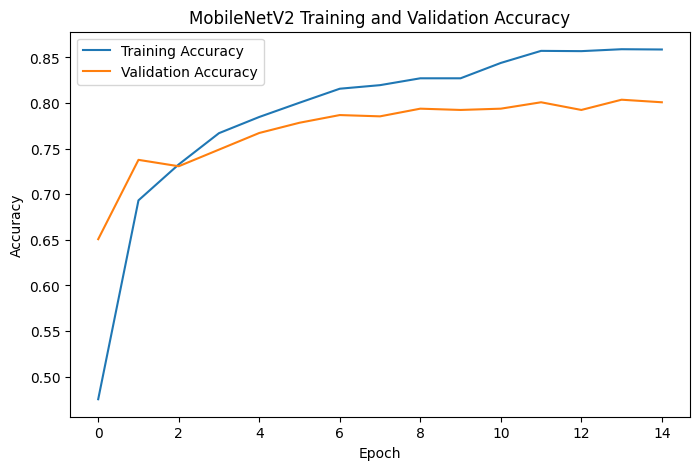

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")

plt.legend()
plt.show()

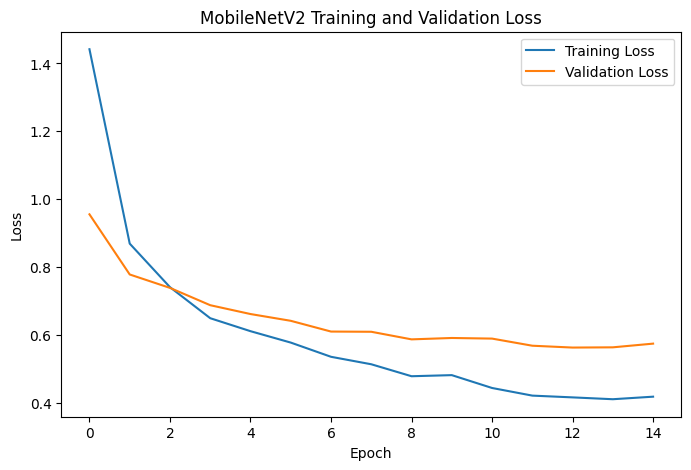

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")

plt.legend()
plt.show()

In [22]:
base_model.trainable = True

In [23]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [24]:
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [25]:
print("Total base model layers:", len(base_model.layers))

print(
    "Trainable layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total base model layers: 154
Trainable layers: 19


In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
fine_tune_epochs = 10

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7
        )
    ]
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 272s 3s/step - accuracy: 0.8440 - loss: 0.4283 - val_accuracy: 0.7966 - val_loss: 0.5728 - learning_rate: 1.0000e-05
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.8599 - loss: 0.3907 - val_accuracy: 0.8121 - val_loss: 0.5410 - learning_rate: 1.0000e-05
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.8797 - loss: 0.3566 - val_accuracy: 0.8093 - val_loss: 0.5411 - learning_rate: 1.0000e-05
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.8758 - loss: 0.3524 - val_accuracy: 0.8247 - val_loss: 0.4969 - learning_rate: 1.0000e-05
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.8857 - loss: 0.3138 - val_accuracy: 0.8275 - val_loss: 0.5326 - learning_rate: 1.0000e-05
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.8948 - loss: 0.2962 - val_accuracy: 0.8233 - val_loss: 0.5086 - learning_rate: 1.0000e-05
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - acc

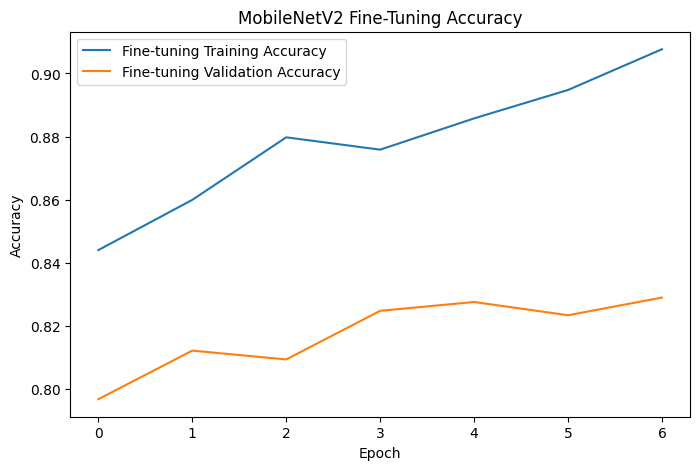

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Fine-tuning Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Fine-tuning Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Fine-Tuning Accuracy")
plt.legend()
plt.show()

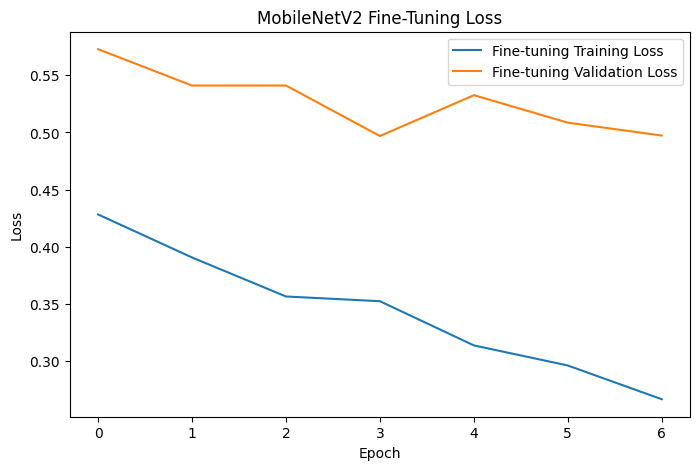

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Fine-tuning Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Fine-tuning Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Fine-Tuning Loss")
plt.legend()
plt.show()

In [30]:
model.save("/content/MobileNetV2_RealWaste.keras")

print("Model saved successfully.")

Model saved successfully.


In [31]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8121 - loss: 0.5474
Test Loss: 0.5473702549934387
Test Accuracy: 0.8120617270469666


In [32]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed.")

Predictions completed.


In [33]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("MobileNetV2 Test Results")
print("-------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

MobileNetV2 Test Results
-------------------------
Accuracy  : 0.8121
Precision : 0.8136
Recall    : 0.8121
F1 Score  : 0.8117


In [34]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

                     precision    recall  f1-score   support

          Cardboard       0.90      0.81      0.85        69
      Food Organics       0.89      0.89      0.89        62
              Glass       0.78      0.81      0.80        63
              Metal       0.78      0.83      0.80       118
Miscellaneous Trash       0.69      0.69      0.69        75
              Paper       0.82      0.93      0.88        75
            Plastic       0.76      0.72      0.74       138
      Textile Trash       0.88      0.77      0.82        48
         Vegetation       0.94      0.92      0.93        65

           accuracy                           0.81       713
          macro avg       0.83      0.82      0.82       713
       weighted avg       0.81      0.81      0.81       713



In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

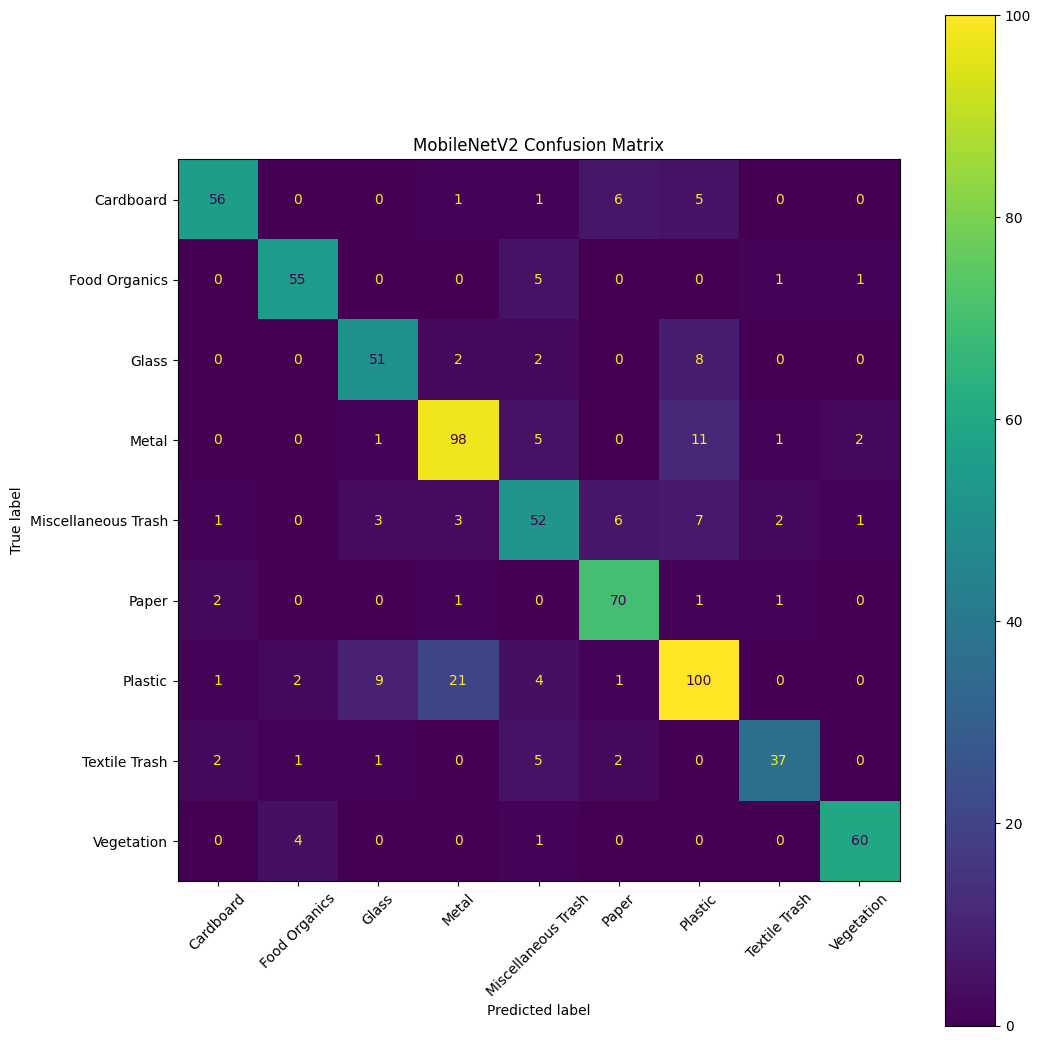

In [36]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(11, 11))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.show()

In [37]:
results_df = pd.DataFrame({
    "Model": ["MobileNetV2"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "Test_Loss": [test_loss]
})

results_df

,Model,Accuracy,Precision,Recall,F1_Score,Test_Loss
0,MobileNetV2,0.812062,0.813555,0.812062,0.811727,0.54737


In [38]:
results_df.to_csv(
    "/content/MobileNetV2_results.csv",
    index=False
)

In [39]:
from google.colab import files

files.download("/content/MobileNetV2_results.csv")
files.download("/content/MobileNetV2_RealWaste.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

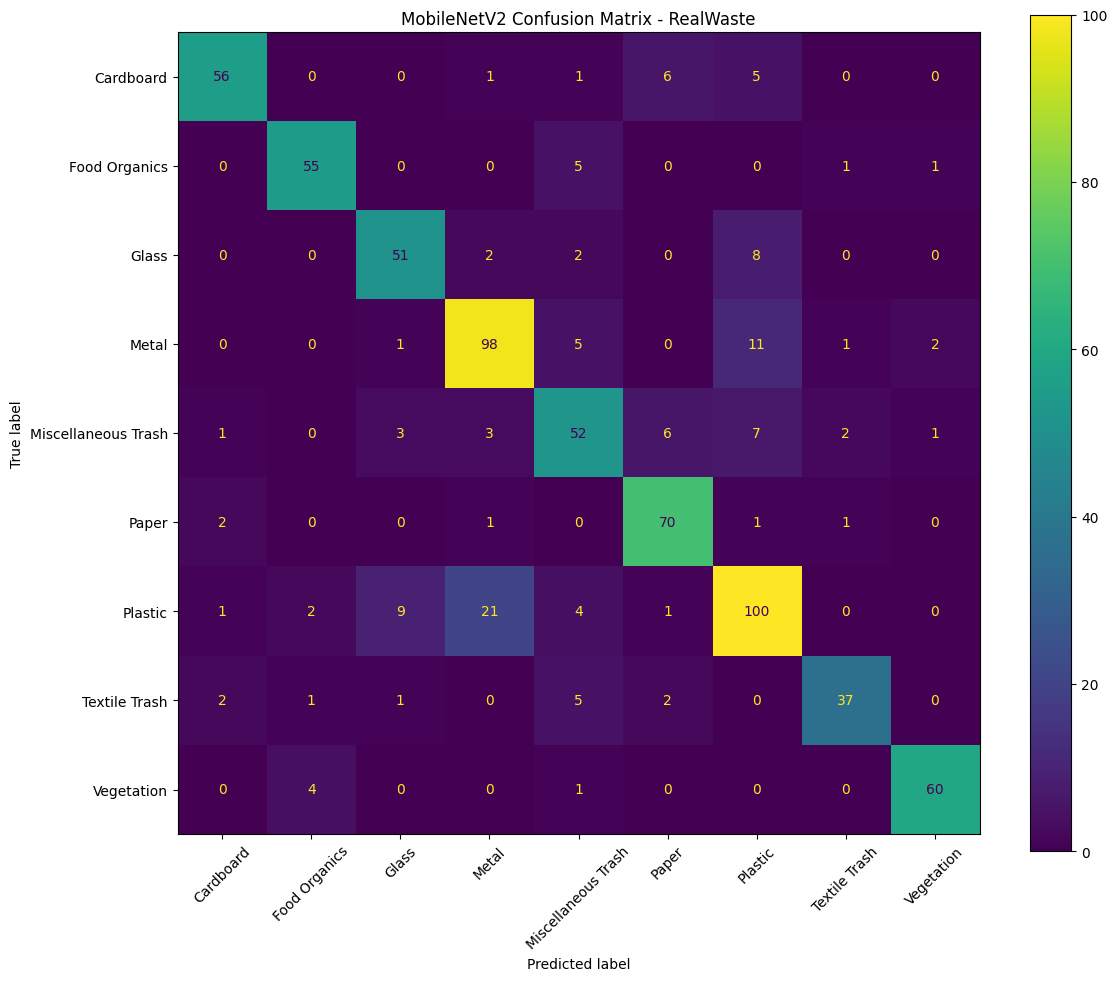

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("MobileNetV2 Confusion Matrix - RealWaste")
plt.tight_layout()

plt.savefig(
    "/content/MobileNetV2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
from google.colab import files

files.download(
    "/content/MobileNetV2_confusion_matrix.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Cardboard,0.903226,0.811594,0.854962,69.000000
Food Organics,0.887097,0.887097,0.887097,62.000000
Glass,0.784615,0.809524,0.796875,63.000000
Metal,0.777778,0.830508,0.803279,118.000000
Miscellaneous Trash,0.693333,0.693333,0.693333,75.000000
Paper,0.823529,0.933333,0.875000,75.000000
Plastic,0.757576,0.724638,0.740741,138.000000
Textile Trash,0.880952,0.770833,0.822222,48.000000
Vegetation,0.937500,0.923077,0.930233,65.000000
accuracy,0.812062,0.812062,0.812062,0.812062


In [44]:
report_df.to_csv(
    "/content/MobileNetV2_classification_report.csv"
)

In [45]:
files.download(
    "/content/MobileNetV2_classification_report.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
results_df = pd.DataFrame({
    "Model": ["MobileNetV2"],
    "Accuracy": [0.8121],
    "Precision": [0.8136],
    "Recall": [0.8121],
    "F1_Score": [0.8117]
})

results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,MobileNetV2,0.8121,0.8136,0.8121,0.8117


In [47]:
results_df.to_csv(
    "/content/MobileNetV2_results.csv",
    index=False
)